<a href="https://colab.research.google.com/github/riggij-sys/Jake-Riggi-Repository/blob/main/Practice_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv'
acc_hits=np.loadtxt(url, delimiter=',')
url2='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv'
acc_fa=np.loadtxt(url2, delimiter=',')
url3='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv'
lc_hits=np.loadtxt(url3, delimiter=',')
url4='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv'
lc_fa=np.loadtxt(url4, delimiter=',')

In [6]:
print(acc_hits.shape)
print(acc_fa.shape)
print(lc_hits.shape)
print(lc_fa.shape)

(14, 8001)
(19, 8001)
(14, 8001)
(19, 8001)


In [16]:
time=np.linspace(0,4,8001)

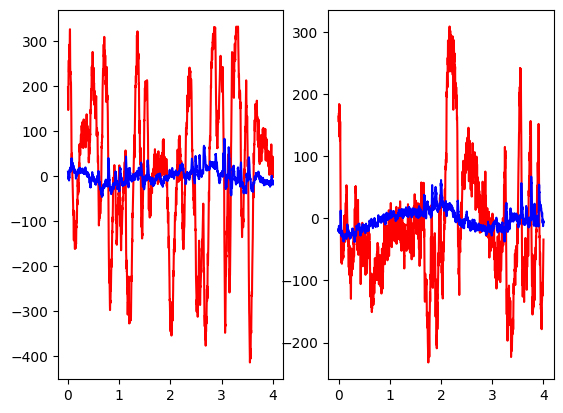

In [19]:
fig, ax = plt.subplots(1,2)
ax[0].plot(time, acc_hits[0], color='red')
ax[0].plot(time,lc_hits[0], color='blue')
ax[1].plot(time, acc_fa[0], color='red')
ax[1].plot(time,lc_fa[0], color='blue')

Text(0.5, 1.0, 'Coherence between two electrodes')

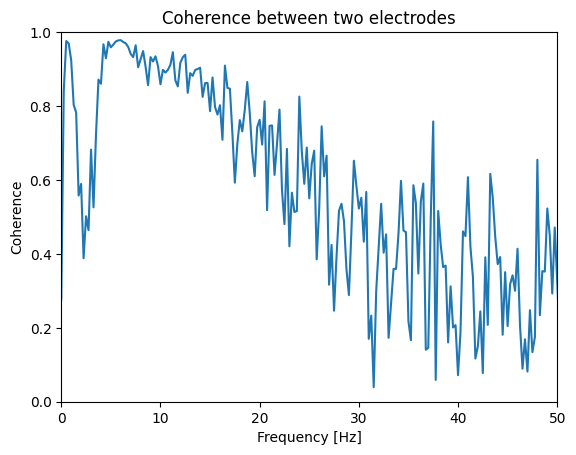

In [32]:
dt = time[1] - time[0]
N = acc_hits.shape[1]

xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)
Syy = scale * (yf * yf.conj()).mean(0)
Sxy = scale * (xf * yf.conj()).mean(0)

cohr1 = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f1 = np.fft.rfftfreq(N, dt)
plt.plot(f1, cohr1.real)
plt.xlim([0, 50])
plt.ylim([0, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

#i don't know why this is wrong,


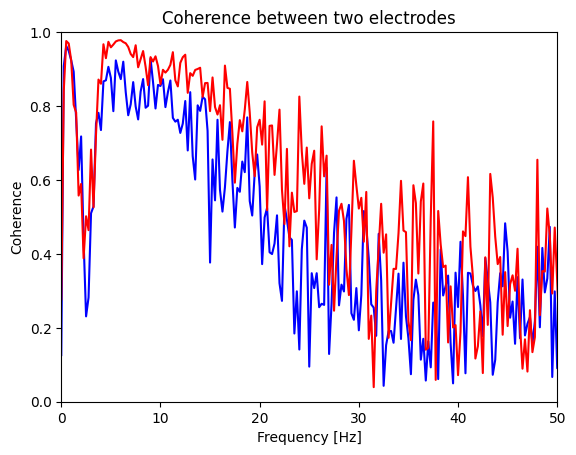

In [34]:
dt = time[1] - time[0]
N = acc_hits.shape[1]

xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_fa])
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_fa])
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)
Syy = scale * (yf * yf.conj()).mean(0)
Sxy = scale * (xf * yf.conj()).mean(0)

cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f = np.fft.rfftfreq(N, dt)
plt.plot(f, cohr.real, color ='blue')
plt.xlim([0, 50])
plt.ylim([0, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

plt.plot(f1, cohr1.real, color='red')
#why do they look exactly the same



